# Zero-shot Quickstart (Multiple Samples)

This quickstart embeds **several** spatial samples together — different sections or donors — and shows that TERRA's embeddings integrate them into a shared space, so cell types and niches line up across samples.

The only differences from the {doc}`single-sample quickstart <zero_shot_quickstart>` are that we concatenate multiple samples into one `AnnData` and pass `sample_key` so each section is tokenized with its own spatial graph.

:::{note}
**TERRA requires an NVIDIA GPU** for the embedding step.
:::

## 1. Setup

In [1]:
import logging

import anndata as ad
import numpy as np
import scanpy as sc
import squidpy as sq

from terra import download_pretrained, harmonize_tokenize_embed_pipeline
from terra.datasets import read_xenium_10x

logging.basicConfig(level="INFO")
sc.settings.set_figure_params(dpi=80, frameon=False)

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 2. Download multiple samples

We use the two serial-section replicates of the 10x Genomics **Xenium Human Breast Cancer** dataset as two samples (~10 MB each). Any two sections sharing the same gene panel work the same way (including two Xenium Prime samples).

In [2]:
def load_sample(base_url, out_dir, sample):
    adata = read_xenium_10x(base_url, out_dir)
    # Namespace cell ids by sample so they stay unique after concatenation.
    adata.obs["sample"] = sample
    adata.obs_names = sample + "_" + adata.obs_names.astype(str)
    adata.obs["cell_id"] = adata.obs_names.astype(str)
    # Crop a contiguous window per section, centred on the median cell
    # position (the bounding-box corner is often empty), to keep things fast.
    xy = adata.obsm["spatial"]
    center = np.median(xy, axis=0)
    keep = (np.abs(xy - center) <= 375).all(axis=1)
    return adata[keep].copy()


base = "https://cf.10xgenomics.com/samples/xenium/1.0.1"
rep1 = load_sample(f"{base}/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1",
                   "data/breast_rep1", "rep1")
rep2 = load_sample(f"{base}/Xenium_FFPE_Human_Breast_Cancer_Rep2/Xenium_FFPE_Human_Breast_Cancer_Rep2",
                   "data/breast_rep2", "rep2")

adata = ad.concat([rep1, rep2])
print(adata.obs["sample"].value_counts())
print(adata)

sample
rep2    3307
rep1    2213
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 5520 × 313
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_id'
    obsm: 'spatial'


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


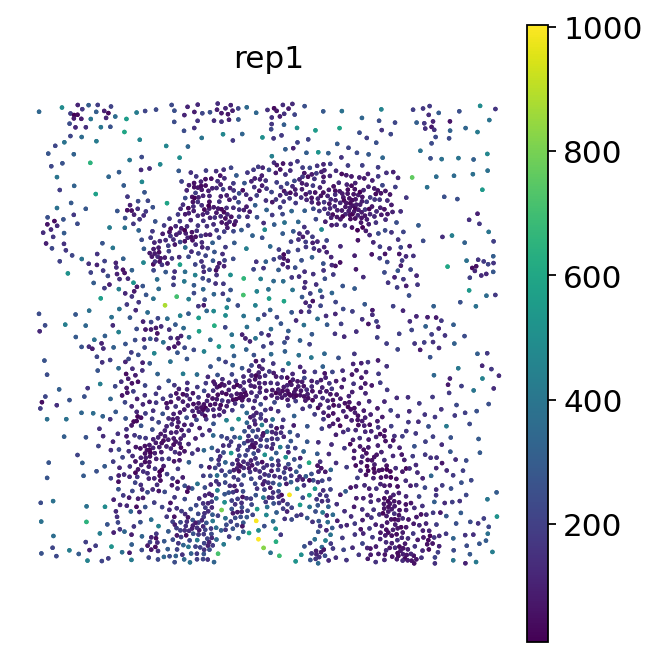

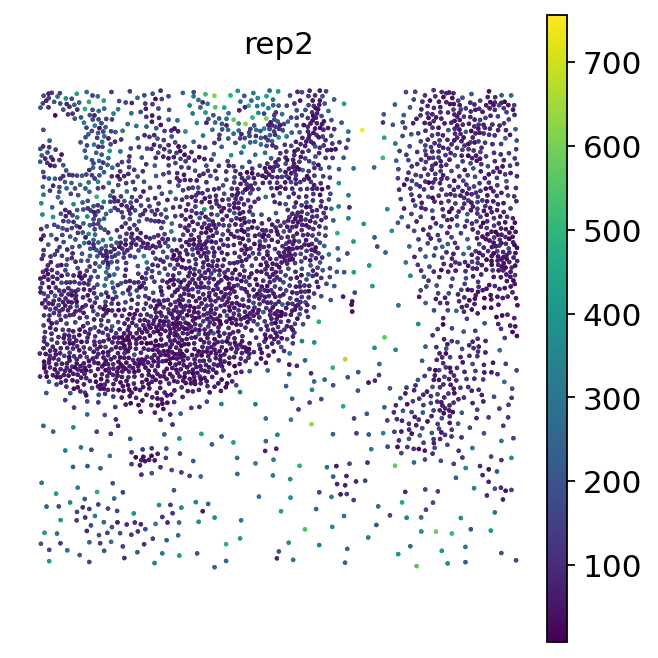

In [3]:
# Total counts per cell, in space, for each section.
adata.obs["total_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()
for sample in adata.obs["sample"].unique():
    sq.pl.spatial_scatter(adata[adata.obs["sample"] == sample],
                          color="total_counts", shape=None, size=4, title=sample)

## 3. Download a pretrained TERRA model

In [4]:
# By default the model is cached in the Hugging Face cache; pass
# local_dir="terra_model" to download it into a folder of your choice.
model_dir = download_pretrained("Lotfollahi-lab/TERRA-112M")

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 200 OK"


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

## 4. Embed all samples together (zero-shot)

Pass `sample_key="sample"` so each section is tokenized with its own spatial neighborhood graph (neighborhoods never cross sections); `batch_key` labels the batch variable for downstream comparison.

In [5]:
adata = harmonize_tokenize_embed_pipeline(
    adata=adata,
    sample_key="sample",      # tokenize each section separately
    batch_key="sample",
    model_folder_path=model_dir,
    cache_directory_path="./terra_cache",
    batch_size=128,           # lower this if you run out of GPU memory
)
print(list(adata.obsm))

INFO:terra.inference.embed:Harmonizing AnnData...
INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 305.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 0 genes.
INFO:terra.inference.harmonize:Before cell filtering: 5520 cells.
INFO:terra.inference.harmonize:After cell filterin

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/harmonize.py:136: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata_gene_names


INFO:terra.tokenizers.cell_tokenizers:Retrieving tokens for neighborhood cells.
INFO:terra.tokenizers.cell_tokenizers:Creating Hugging Face dataset...
INFO:terra.tokenizers.cell_tokenizers:Using generator for dataset creation.
INFO:terra.tokenizers.cell_tokenizers:Formatting gene tokens...
INFO:terra.inference.embed:Tokenized sample rep1.
INFO:terra.inference.embed:Start processing sample: rep2...
INFO:terra.inference.embed:Harmonizing sample rep2...
INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.har

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/harmonize.py:136: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata_gene_names


INFO:terra.tokenizers.cell_tokenizers:Retrieving tokens for neighborhood cells.
INFO:terra.tokenizers.cell_tokenizers:Creating Hugging Face dataset...
INFO:terra.tokenizers.cell_tokenizers:Using generator for dataset creation.
INFO:terra.tokenizers.cell_tokenizers:Formatting gene tokens...
INFO:terra.inference.embed:Tokenized sample rep2.
INFO:terra.inference.embed:Concatenating tokenized data...
INFO:terra.inference.embed:Concatenated tokenized data.
INFO:terra.inference.embed:Embedding tokenized data...
INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.


...

INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, el

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:26,  1.96s/it]

INFO:terra.inference.embed:Embedded tokenized data.
['spatial', 'cell_emb', 'neighborhood_emb', 'spatial_cell_emb']


## 5. Visualize — do the samples integrate?

Color the UMAP by `sample`. Well-integrated embeddings mix the sections (shared biology overlaps) rather than separating by batch.

... storing 'sample' as categorical


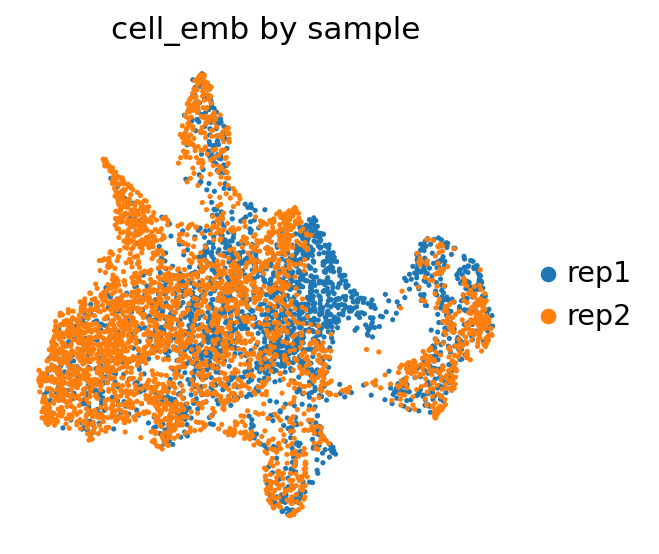

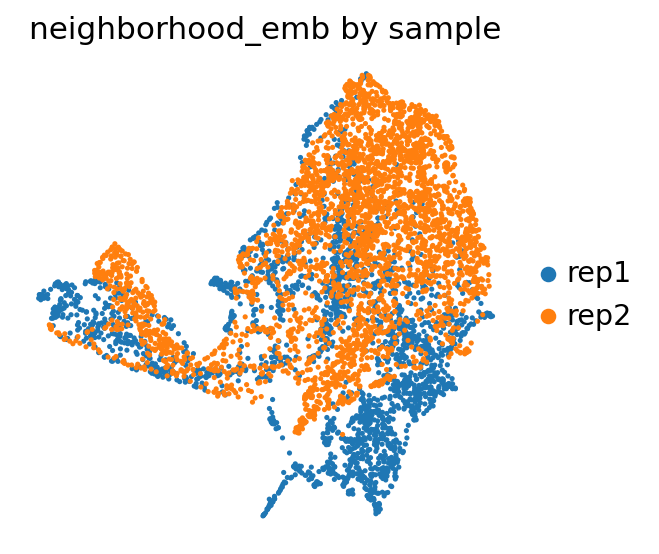

In [6]:
for emb_key in ["cell_emb", "neighborhood_emb"]:
    sc.pp.neighbors(adata, use_rep=emb_key, key_added=emb_key)
    sc.tl.umap(adata, neighbors_key=emb_key)
    sc.pl.umap(adata, neighbors_key=emb_key, color="sample", title=f"{emb_key} by sample")

## 6. Niche & cell-type identification across samples

Cluster each embedding once across all sections: niches from `neighborhood_emb`
and cell types from `cell_emb`. Because the embeddings are integrated, the same
clusters span both sections.

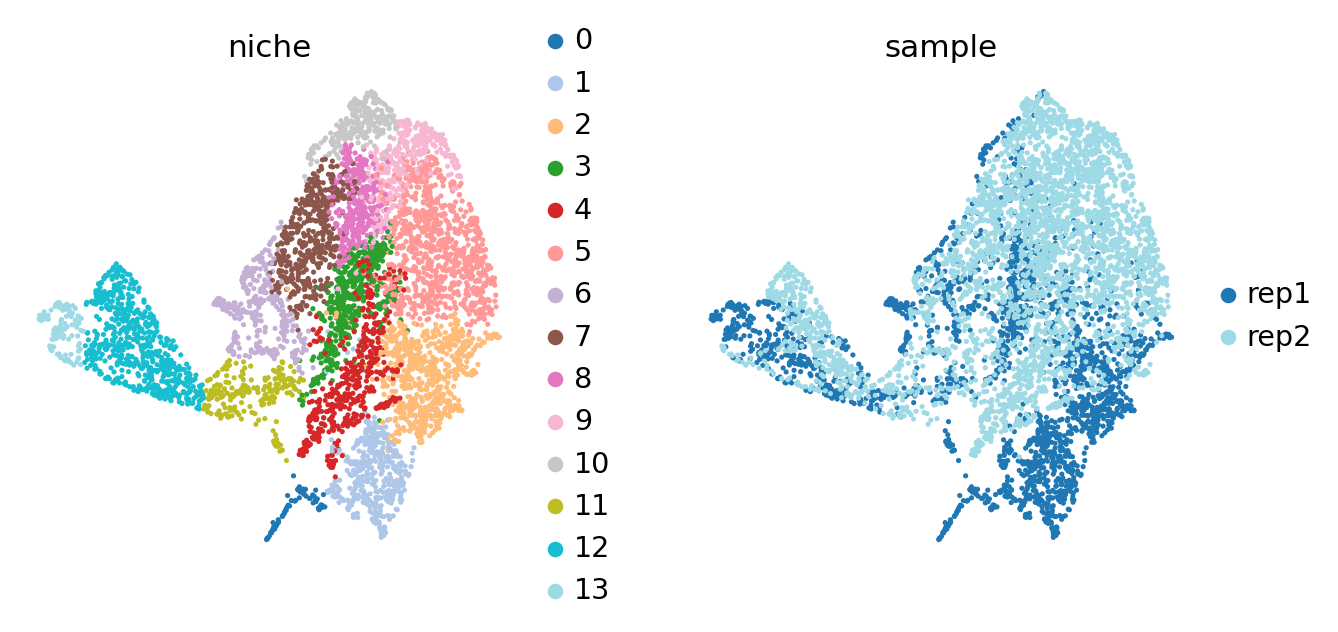

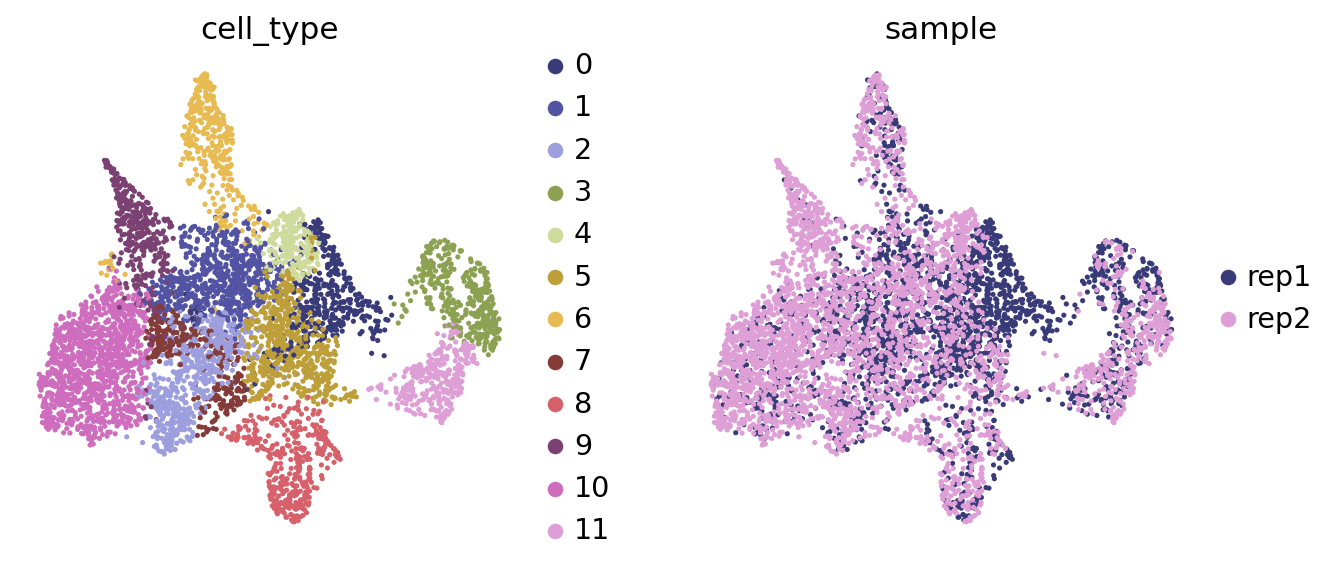

In [7]:
sc.tl.leiden(adata, neighbors_key="neighborhood_emb", key_added="niche",
             resolution=0.6, flavor="igraph", n_iterations=2, directed=False)
sc.tl.leiden(adata, neighbors_key="cell_emb", key_added="cell_type",
             resolution=0.6, flavor="igraph", n_iterations=2, directed=False)

# Niches on the neighborhood-embedding UMAP, cell types on the cell-embedding
# UMAP, each with its own colour palette.
sc.tl.umap(adata, neighbors_key="neighborhood_emb")
sc.pl.umap(adata, neighbors_key="neighborhood_emb", color=["niche", "sample"],
           palette="tab20")

sc.tl.umap(adata, neighbors_key="cell_emb")
sc.pl.umap(adata, neighbors_key="cell_emb", color=["cell_type", "sample"],
           palette="tab20b")

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


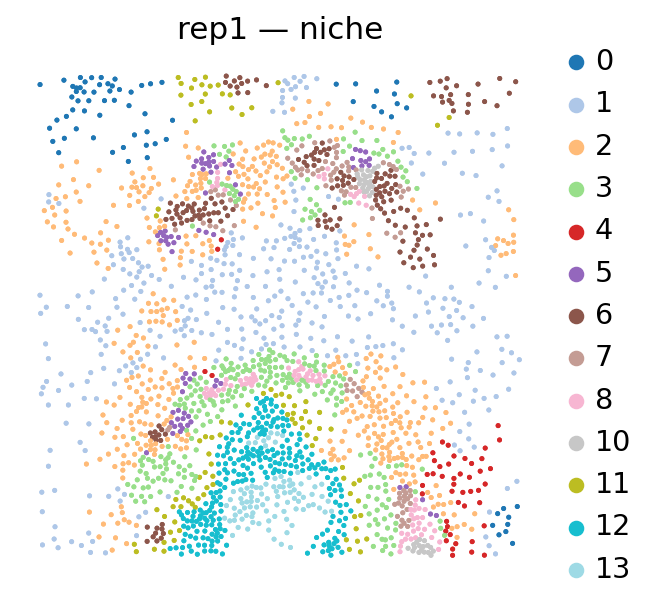

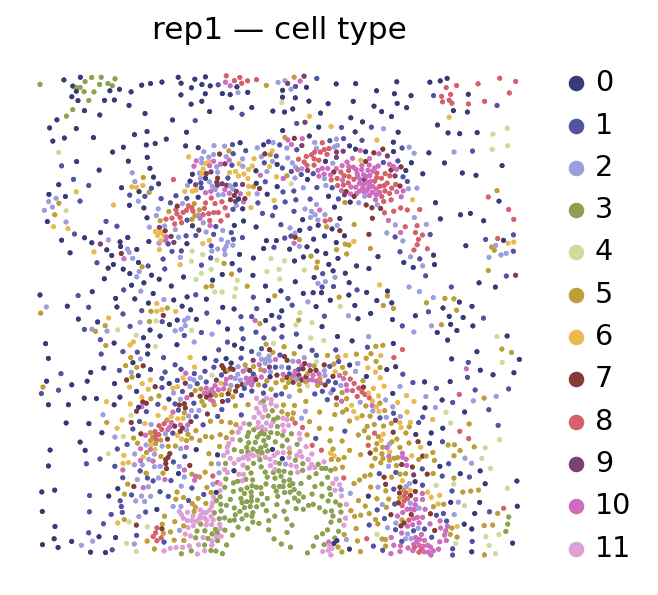

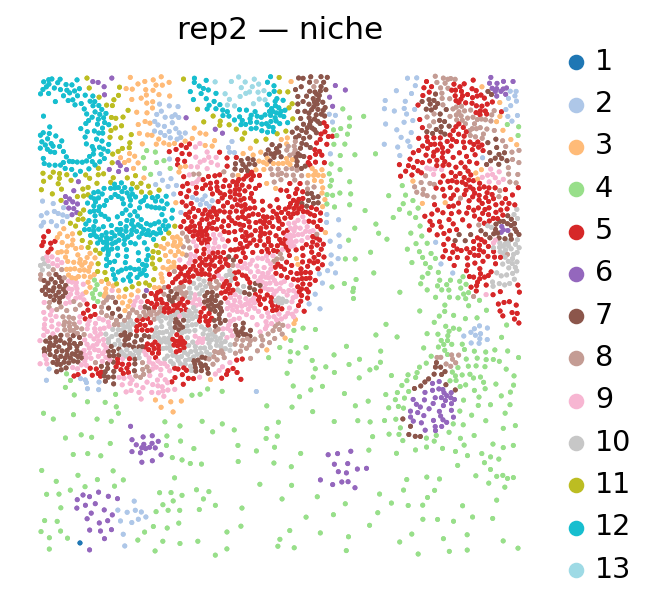

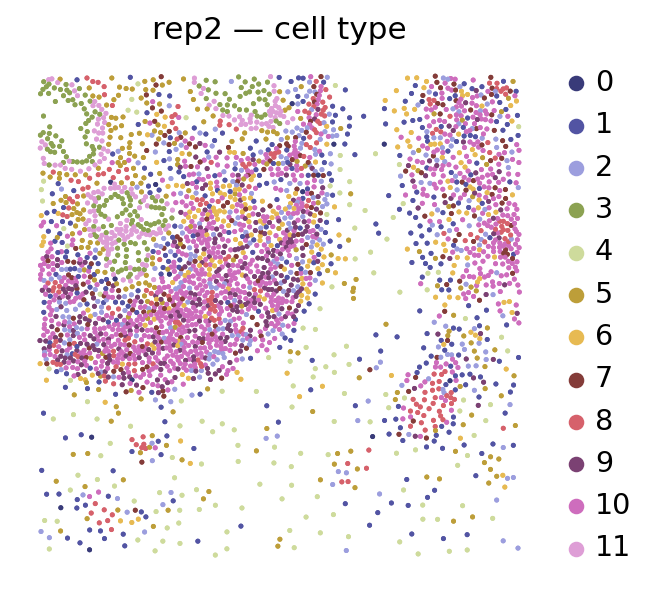

In [8]:
# The shared niches and cell types, shown in space for each section, each with
# its own colour palette.
for sample in adata.obs["sample"].unique():
    sub = adata[adata.obs["sample"] == sample]
    sq.pl.spatial_scatter(sub, color="niche", shape=None, size=6,
                          palette="tab20", title=f"{sample} — niche")
    sq.pl.spatial_scatter(sub, color="cell_type", shape=None, size=6,
                          palette="tab20b", title=f"{sample} — cell type")

## Next steps

- {doc}`downstream_analysis` — gene-level embeddings, spatial gene-pair scoring, EMD spatial structure, and in-silico perturbation.
- {doc}`xenium_finetuning` — adapt the pretrained model to your own data with self-supervised LoRA fine-tuning.

**Questions or issues?** Please report them on the [TERRA GitHub repository](https://github.com/Lotfollahi-lab/terra/issues).